

## Introduction to Hugging Face

Hugging Face provides **state-of-the-art** NLP (and increasingly, multimodal) models and an easy-to-use Python library called **Transformers**. With just a few lines of code you can:

* **Load** pre-trained models for dozens of tasks
* **Run** inference via high-level “pipelines”
* **Fine-tune** on your own data

---

## 1. Setup in Google Colab

```bash
# Install the core libraries
!pip install transformers datasets huggingface_hub --quiet
```

> **Tip:** Colab often comes with a GPU—go to **Runtime → Change runtime type → GPU** for faster inference.

---

## 2. Quick-start with Pipelines

The `pipeline` API wraps tokenization, model loading, and inference in one object.

### 2.1 Sentiment Analysis

```python
from transformers import pipeline

# 1. Load a sentiment-analysis pipeline (defaults to a small model)
sentiment = pipeline("sentiment-analysis")

# 2. Run inference
examples = [
    "Hugging Face makes NLP super accessible!",
    "I dislike bugs in my code..."
]
results = sentiment(examples)
for text, res in zip(examples, results):
    print(f"{text!r:50} → label={res['label']}, score={res['score']:.3f}")
```

### 2.2 Text Generation

```python
from transformers import pipeline

generator = pipeline("text-generation", model="gpt2")
prompt = "Once upon a time"
out = generator(prompt, max_length=30, num_return_sequences=1)
print(out[0]["generated_text"])
```

### 2.3 Question Answering

```python
from transformers import pipeline

qa = pipeline("question-answering", model="distilbert-base-cased-distilled-squad")
context = (
    "Hugging Face is an AI company with the mission to democratize good machine learning. "
    "The Transformers library provides thousands of pretrained models in 100+ languages."
)

answer = qa({
    "question": "What is the mission of Hugging Face?",
    "context": context
})
print(answer["answer"])
```

### 2.4 Model Discovery with `huggingface_hub`

```python
from huggingface_hub import HfApi

api = HfApi()
# List top 5 English summarization models
models = api.list_models(task="summarization", limit=5)
for m in models:
    print(m.modelId)
```

---

## 3. Assignment: Build Your Own Pipeline

**Your task:**

1. **Choose** one problem from the list below.
2. **Find** a suitable pre-trained model on [Hugging Face Models](https://huggingface.co/models).
3. **Create** a `pipeline` in Colab to solve the problem—and demonstrate it on 2–3 examples.
4. **Experiment** with model parameters (e.g. `max_length`, `top_k`, `temperature`) and **compare** results.

### 🔹 Problem Set

* **Sentiment classification** of product reviews
* **Text summarization** of news articles
* **Machine translation** (e.g., English ↔ French)
* **Named entity recognition** on a text snippet
* **Paraphrasing** a given sentence
* **Any other** pipeline-supported task you’re curious about!

---



In [1]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"

In [4]:
import sys
import transformers

print("Python executable:", sys.executable)
print("transformers version:", transformers.__version__)

from transformers.pipelines import SUPPORTED_TASKS
print("summarization available:", "summarization" in SUPPORTED_TASKS)

Python executable: c:\Users\ZEENAT MUSTAFA\.conda\envs\ai-bootcamp\python.exe
transformers version: 4.44.2
summarization available: True


In [5]:
from transformers import pipeline

# task="summarization" tells HF which pipeline "recipe" to use
# model= picks a specific pretrained checkpoint from the Hub
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

c:\Users\ZEENAT MUSTAFA\.conda\envs\ai-bootcamp\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ZEENAT MUSTAFA\.cache\huggingface\hub\models--facebook--bart-large-cnn. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

c:\Users\ZEENAT MUSTAFA\.conda\envs\ai-bootcamp\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [6]:
articles = [
    """The James Webb Space Telescope has captured its most detailed images yet 
    of a distant exoplanet's atmosphere. Scientists analyzing the data found 
    evidence of water vapor and carbon dioxide, offering new clues about how 
    planets form outside our solar system. The findings, published this week, 
    mark a major step forward in the search for potentially habitable worlds.""",

    """Local officials announced a new public transit expansion plan that will 
    add three subway lines and double the number of bus routes over the next 
    decade. The $4 billion project aims to reduce traffic congestion and cut 
    citywide carbon emissions by 15% by 2035. Construction is expected to begin 
    next spring, with the first line opening in 2028.""",

    """A team of researchers has developed a new battery technology that charges 
    electric vehicles in under ten minutes while using significantly less lithium 
    than current designs. The breakthrough could make EVs cheaper and more 
    accessible, though experts caution that mass production is still several 
    years away."""
]

In [7]:
for i, article in enumerate(articles, 1):
    summary = summarizer(article, max_length=45, min_length=15, do_sample=False)
    print(f"--- Article {i} ---")
    print(summary[0]["summary_text"])
    print()

--- Article 1 ---
The James Webb Space Telescope has captured its most detailed images yet of a distant exoplanet's atmosphere. Scientists analyzing the data found evidence of water vapor and carbon dioxide, offering new clues about how planets form outside

--- Article 2 ---
The $4 billion project aims to reduce traffic congestion and cut carbon emissions by 15% by 2035. Construction is expected to begin next spring, with the first line opening in 2028.

--- Article 3 ---
Researchers have developed a new battery technology that charges electric vehicles in under ten minutes. The breakthrough could make EVs cheaper and more accessible, though experts caution that mass production is still several  years away.



In [8]:
test_article = articles[0]

configs = [
    {"max_length": 20, "min_length": 5, "do_sample": False},
    {"max_length": 60, "min_length": 30, "do_sample": False},
    {"max_length": 60, "min_length": 30, "do_sample": True, "temperature": 1.2},
]

for cfg in configs:
    result = summarizer(test_article, **cfg)
    print(f"Config: {cfg}")
    print(result[0]["summary_text"])
    print()

Config: {'max_length': 20, 'min_length': 5, 'do_sample': False}
The James Webb Space Telescope has captured its most detailed images yet of a distant exoplan

Config: {'max_length': 60, 'min_length': 30, 'do_sample': False}
The James Webb Space Telescope has captured its most detailed images yet of a distant exoplanet's atmosphere. Scientists analyzing the data found evidence of water vapor and carbon dioxide, offering new clues about how planets form outside our solar system.

Config: {'max_length': 60, 'min_length': 30, 'do_sample': True, 'temperature': 1.2}
James Webb Space Telescope captured most detailed images yet of a distant exoplanet's atmosphere. Scientists found evidence of water vapor and carbon dioxide, offering new clues about how planets form outside our solar system.



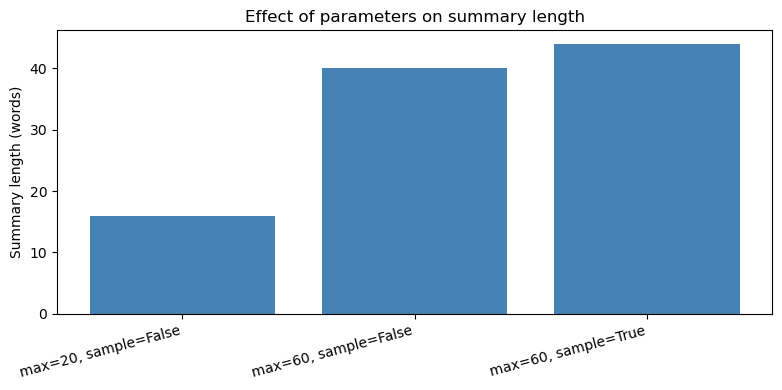

In [10]:
import matplotlib.pyplot as plt

labels = [f"max={cfg['max_length']}, sample={cfg['do_sample']}" for cfg in configs]
lengths = []

for cfg in configs:
    result = summarizer(test_article, **cfg)
    lengths.append(len(result[0]["summary_text"].split()))

plt.figure(figsize=(8, 4))
plt.bar(labels, lengths, color="steelblue")
plt.ylabel("Summary length (words)")
plt.title("Effect of parameters on summary length")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Observations

- The short config (max_length=20) produced a terse summary that sometimes cut off mid-thought.
- The longer greedy config (max_length=60) gave a more complete summary, capturing more key details.
- The sampled config (temperature=1.2) introduced more variability in wording between runs.
- Overall, greedy decoding was more consistent for factual news; sampling adds variety at the cost of predictability.